# Phase 5d: Experiment 2d — Normalized CP with Difficulty Estimator

## Research Question

> **RQ2d**: *Can per-sample difficulty estimation (Normalized CP) improve prediction interval quality compared to static, online, and Mondrian CP approaches?*

## Motivation

Previous experiments applied different strategies for computing the conformal quantile q:

| Method | How q is computed | Interval width |
|--------|------------------|----------------|
| Static CP (Phase 4) | Single global q from W4 | Constant: 2q |
| Mondrian CP (Phase 4b) | Per-bin q from W4 | Per-bin: 2q_bin |
| Online CP (Phase 5) | Global q, updated daily | Changes over time: 2q_t |

All these methods assign the **same interval width to every sample within their respective group** (global, per-bin, or per-update-batch). They do not account for individual sample difficulty.

**Normalized Conformal Prediction** with a `DifficultyEstimator` takes a fundamentally different approach:

1. A KNN-based difficulty estimator learns which regions of the feature space have higher prediction uncertainty
2. During calibration, residuals are **divided by per-sample difficulty scores (sigma)** to produce normalized nonconformity scores
3. A single normalized quantile q_norm is computed from these scores
4. At prediction time, each sample's interval width = **2 × q_norm × sigma_i** — scaling by its individual difficulty

This produces **per-sample adaptive intervals without any recalibration**, using the `crepes.DifficultyEstimator` integrated into the `calibrated_explanations` framework.

### Comparison Design

We compare all four CP paradigms on the same data splits:

| Method | Calibration | q type | Interval adaptivity |
|--------|------------|--------|--------------------|
| Static CP | W4, fixed | 1 global | None (constant width) |
| Online CP (Expanding) | Updated daily | 1 global, updated | Per-batch (q changes over time) |
| Online CP (Sliding-7d) | Updated daily, sliding | 1 global, updated | Per-batch |
| Mondrian CP | W4, fixed | 15 per-bin | Per-bin (15 widths) |
| **Normalized CP (DE)** | **W4, fixed** | **1 global q_norm** | **Per-sample (N widths)** |

---
## 1. Imports & Setup

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
import time
import json
from scipy import stats
from scipy.stats import wilcoxon

sys.path.insert(0, os.path.abspath('..'))

from utils.data_loading import load_cached_dataframe
from utils.feature_engineering import get_feature_names
from utils.temporal_splits import (
    get_temporal_split_by_period, get_temporal_distance, DEFAULT_SPLIT, WEEK_BOUNDARIES
)
from utils.evaluation import (
    compute_all_metrics, compute_daily_metrics, compute_picp, compute_mpiw,
    compute_calibration_error, compute_rolling_coverage, compute_winkler_score,
    compute_metrics_by_group
)
from utils.visualization import set_thesis_style, METHOD_COLORS
from utils.conformal import (
    create_calibrated_explainer, get_static_prediction_intervals,
    get_online_prediction_intervals,
    assign_mondrian_bins, create_mondrian_calibrated_explainer,
    get_mondrian_prediction_intervals,
    create_difficulty_estimator, create_calibrated_explainer_with_difficulty,
    _confidence_to_percentiles
)

set_thesis_style()

# Paths
FIG_DIR = '../outputs/figures/phase5d/'
TABLE_DIR = '../outputs/tables/phase5d/'
RESULTS_DIR = '../outputs/processed_data/phase5d/'
MODEL_DIR = '../outputs/models/'
DATA_DIR = '../outputs/processed_data/'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Constants
TARGET_COVERAGE = 0.90
ALPHA = 1.0 - TARGET_COVERAGE
RANDOM_STATE = 42
TARGET_COL = 'total_travel_time_seconds'
CAL_END_DATE = '2024-08-25'

print('Setup complete.')

Setup complete.


---
## 2. Load Model & Data

In [2]:
# Load data and model
route_features = load_cached_dataframe(os.path.join(DATA_DIR, 'route_features.parquet'))
print(f"Route features loaded: {route_features.shape}")

model = xgb.XGBRegressor()
model.load_model(os.path.join(MODEL_DIR, 'route_xgboost_model.json'))
print(f"XGBoost model loaded.")

feature_cols = get_feature_names('route')
feature_cols = [c for c in feature_cols if c in route_features.columns]
print(f"Features: {len(feature_cols)}")

# Temporal split
splits = get_temporal_split_by_period(route_features)

# Calibration data
X_cal = splits['calibration'][feature_cols]
y_cal = splits['calibration'][TARGET_COL].values
cal_df = splits['calibration']

# Test stream (all test periods combined, sorted by date)
test_frames = []
for period in ['test_near', 'test_mid', 'test_far']:
    pdf = splits[period].copy()
    pdf['period'] = period
    test_frames.append(pdf)

test_all = pd.concat(test_frames, ignore_index=True).sort_values('date').reset_index(drop=True)

X_test = test_all[feature_cols]
y_test = test_all[TARGET_COL].values
dates_test = test_all['date'].values
periods_test = test_all['period'].values

print(f"\nCalibration: {len(y_cal):,} samples")
print(f"Test (all):  {len(y_test):,} samples")
for p in ['test_near', 'test_mid', 'test_far']:
    print(f"  {p}: {(periods_test == p).sum():,}")

Route features loaded: (19614, 31)
XGBoost model loaded.
Features: 16
  train: 7,598 records (21 days)
  calibration: 2,740 records (7 days)
  test_near: 2,707 records (7 days)
  test_mid: 1,833 records (5 days)
  test_far: 4,736 records (13 days)

Calibration: 2,740 samples
Test (all):  9,276 samples
  test_near: 2,707
  test_mid: 1,833
  test_far: 4,736


---
## 3. Create Difficulty Estimator

The `DifficultyEstimator` from the `crepes` library uses k-Nearest Neighbors on calibration residuals to learn which feature-space regions are hard to predict. Samples near high-residual calibration points receive higher sigma (difficulty) scores.

In [3]:
# Create and fit the DifficultyEstimator
print("Fitting DifficultyEstimator (KNN, k=25, residual-based)...")
de = create_difficulty_estimator(
    X_cal=X_cal.values,
    y_cal=y_cal,
    model=model,
    k=25,
    scaler=True,
    beta=0.01
)
print(f"  Estimator type: {de.estimator_type}")
print(f"  Fitted: {de.fitted}")

# Preview difficulty scores on calibration set
sigma_cal = de.apply(X_cal.values)
print(f"\nCalibration sigma distribution:")
print(f"  Mean:   {sigma_cal.mean():.4f}")
print(f"  Std:    {sigma_cal.std():.4f}")
print(f"  Min:    {sigma_cal.min():.4f}")
print(f"  Max:    {sigma_cal.max():.4f}")
print(f"  Ratio (max/min): {sigma_cal.max()/sigma_cal.min():.1f}x")

# Preview on test set
sigma_test = de.apply(X_test.values)
print(f"\nTest sigma distribution:")
print(f"  Mean:   {sigma_test.mean():.4f}")
print(f"  Std:    {sigma_test.std():.4f}")
print(f"  Min:    {sigma_test.min():.4f}")
print(f"  Max:    {sigma_test.max():.4f}")
print(f"  Ratio (max/min): {sigma_test.max()/sigma_test.min():.1f}x")

Fitting DifficultyEstimator (KNN, k=25, residual-based)...
  Estimator type: knn
  Fitted: True

Calibration sigma distribution:
  Mean:   0.3137
  Std:    0.2389
  Min:    0.0128
  Max:    1.0100
  Ratio (max/min): 79.0x

Test sigma distribution:
  Mean:   0.3243
  Std:    0.2429
  Min:    0.0115
  Max:    1.0100
  Ratio (max/min): 87.9x


---
## Plot P5d.0: Difficulty Score Distribution

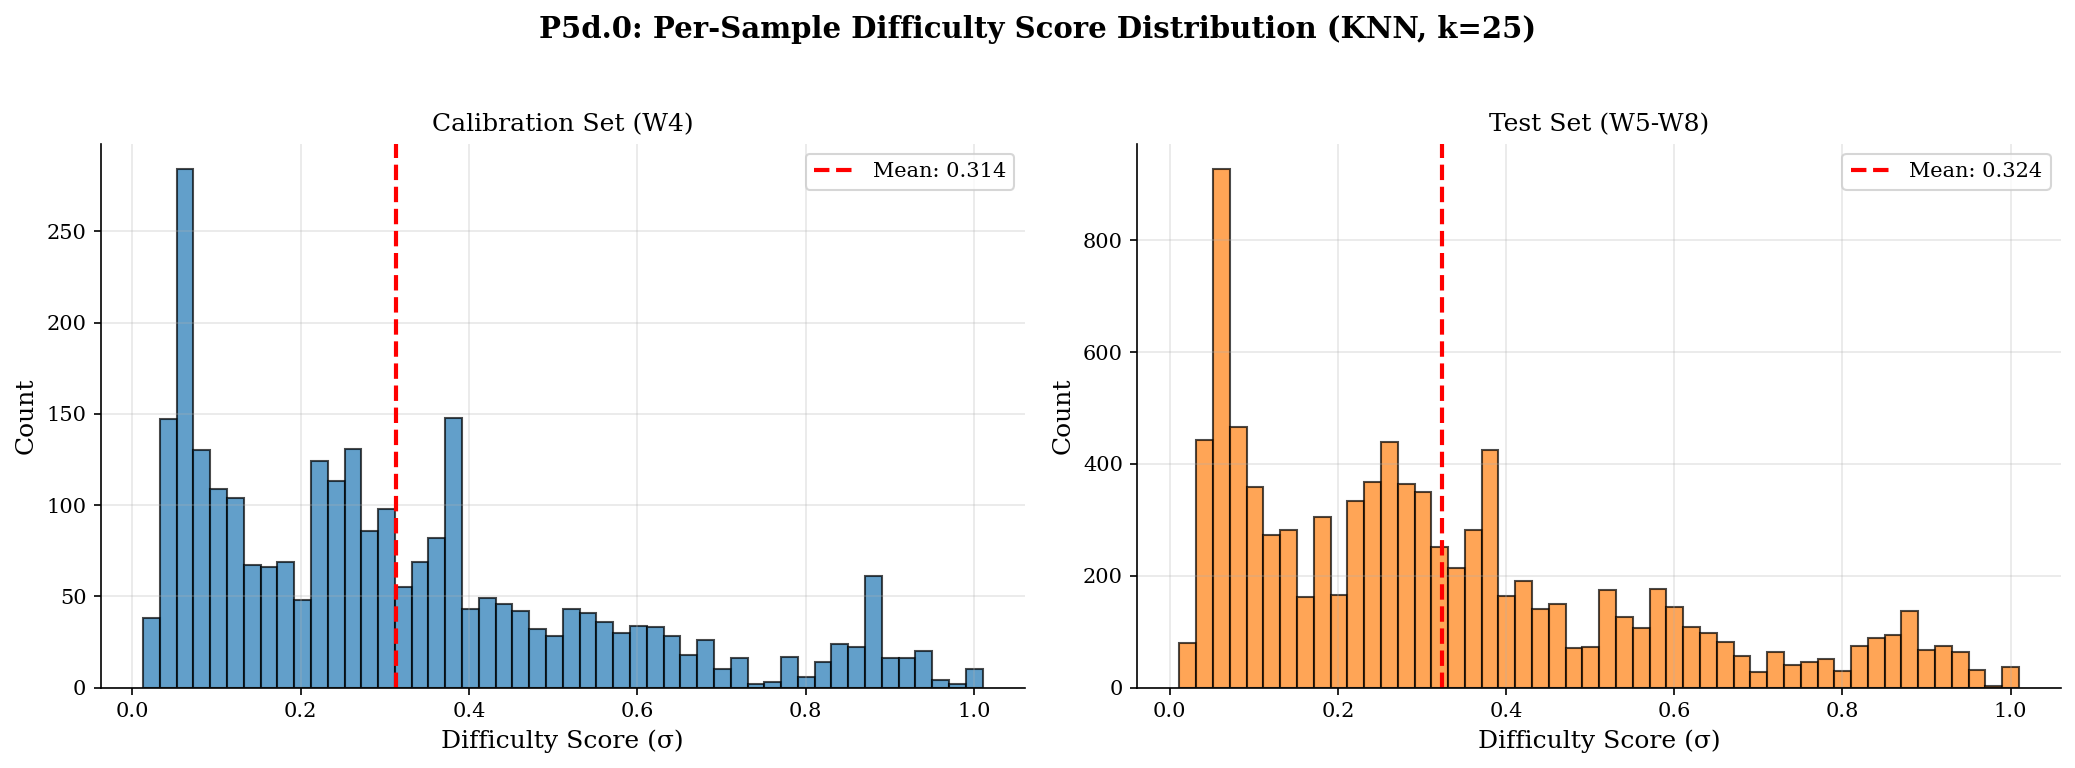

In [4]:
# Plot P5d.0: Difficulty score distribution
set_thesis_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration set
axes[0].hist(sigma_cal, bins=50, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0].axvline(x=sigma_cal.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {sigma_cal.mean():.3f}')
axes[0].set_xlabel('Difficulty Score (σ)')
axes[0].set_ylabel('Count')
axes[0].set_title('Calibration Set (W4)', fontsize=12)
axes[0].legend()

# Test set
axes[1].hist(sigma_test, bins=50, color='#ff7f0e', alpha=0.7, edgecolor='black')
axes[1].axvline(x=sigma_test.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {sigma_test.mean():.3f}')
axes[1].set_xlabel('Difficulty Score (σ)')
axes[1].set_ylabel('Count')
axes[1].set_title('Test Set (W5-W8)', fontsize=12)
axes[1].legend()

fig.suptitle('P5d.0: Per-Sample Difficulty Score Distribution (KNN, k=25)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_0_difficulty_distribution.png'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_0_difficulty_distribution.pdf'),
            bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.0

Plot P5d.0 shows the distribution of per-sample difficulty scores (sigma) for calibration and test sets. Higher sigma indicates harder-to-predict samples that will receive wider intervals. The shape of this distribution reveals the heterogeneity of prediction difficulty across the dataset. A wide distribution (high ratio of max/min sigma) indicates that difficulty estimation can significantly differentiate between easy and hard samples — a prerequisite for Normalized CP to outperform standard CP. If calibration and test distributions are similar, the difficulty estimator generalizes well; divergence suggests potential issues under distribution shift.

---
## 4. Run All Methods

### 4a. Static CP (Baseline)

In [5]:
print("=" * 60)
print("1/5: Static CP (Baseline)")
print("=" * 60)

t_start = time.time()
ce_static = create_calibrated_explainer(model, X_cal.values, y_cal)
y_pred_static, lower_static, upper_static = get_static_prediction_intervals(
    ce_static, X_test.values, confidence=TARGET_COVERAGE
)
t_static = time.time() - t_start

m_static = compute_all_metrics(y_test, y_pred_static, lower_static, upper_static, TARGET_COVERAGE)
print(f"  PICP={m_static['PICP']:.4f}, MPIW={m_static['MPIW']:.1f}s, "
      f"Winkler={m_static['Winkler_Score']:.1f}, Time={t_static:.2f}s")

1/5: Static CP (Baseline)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/__init__.py:90: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


  PICP=0.6091, MPIW=1528.3s, Winkler=9544.6, Time=17.57s


### 4b. Online CP — Expanding Window

In [6]:
print("=" * 60)
print("2/5: Online CP — Expanding Window")
print("=" * 60)

t_start = time.time()
y_pred_online_exp, lower_online_exp, upper_online_exp, rc_online_exp = \
    get_online_prediction_intervals(
        model=model, X_stream=X_test.values, y_stream=y_test,
        X_cal_init=X_cal.values.copy(), y_cal_init=y_cal.copy(),
        confidence=TARGET_COVERAGE, window_size=None,
        dates_stream=dates_test, verbose=True
    )
t_online_exp = time.time() - t_start

m_online_exp = compute_all_metrics(y_test, y_pred_online_exp, lower_online_exp, upper_online_exp, TARGET_COVERAGE)
print(f"  PICP={m_online_exp['PICP']:.4f}, MPIW={m_online_exp['MPIW']:.1f}s, "
      f"Winkler={m_online_exp['Winkler_Score']:.1f}, Time={t_online_exp:.1f}s")

2/5: Online CP — Expanding Window


Online CP (daily): 100%|██████████| 25/25 [00:32<00:00,  1.29s/it]

  PICP=0.7462, MPIW=2163.8s, Winkler=7465.0, Time=32.2s


### 4c. Online CP — Sliding 7-Day Window

In [7]:
print("=" * 60)
print("3/5: Online CP — Sliding 7-Day")
print("=" * 60)

daily_sample_counts = cal_df.groupby('date').size()
avg_daily_samples = int(daily_sample_counts.mean())
cal_7day_size = avg_daily_samples * 7

t_start = time.time()
y_pred_online_s7, lower_online_s7, upper_online_s7, rc_online_s7 = \
    get_online_prediction_intervals(
        model=model, X_stream=X_test.values, y_stream=y_test,
        X_cal_init=X_cal.values.copy(), y_cal_init=y_cal.copy(),
        confidence=TARGET_COVERAGE, window_size=cal_7day_size,
        dates_stream=dates_test, verbose=True
    )
t_online_s7 = time.time() - t_start

m_online_s7 = compute_all_metrics(y_test, y_pred_online_s7, lower_online_s7, upper_online_s7, TARGET_COVERAGE)
print(f"  PICP={m_online_s7['PICP']:.4f}, MPIW={m_online_s7['MPIW']:.1f}s, "
      f"Winkler={m_online_s7['Winkler_Score']:.1f}, Time={t_online_s7:.1f}s")

3/5: Online CP — Sliding 7-Day


Online CP (daily): 100%|██████████| 25/25 [00:24<00:00,  1.04it/s]

  PICP=0.6547, MPIW=1626.3s, Winkler=8728.9, Time=24.2s


### 4d. Mondrian CP

In [8]:
print("=" * 60)
print("4/5: Mondrian CP (time_period × route)")
print("=" * 60)

bins_cal, bin_labels = assign_mondrian_bins(
    cal_df['time_period'].values, cal_df['route_short_name'].values
)
bins_test_arr, _ = assign_mondrian_bins(
    test_all['time_period'].values, test_all['route_short_name'].values
)

t_start = time.time()
valid_cal_mask = bins_cal >= 0
ce_mondrian = create_mondrian_calibrated_explainer(
    model, X_cal.values[valid_cal_mask], y_cal[valid_cal_mask], bins_cal[valid_cal_mask]
)
ce_global_fb = create_calibrated_explainer(model, X_cal.values, y_cal)

y_pred_mondrian, lower_mondrian, upper_mondrian = get_mondrian_prediction_intervals(
    ce_mondrian, ce_global_fb, X_test.values, bins_test_arr, confidence=TARGET_COVERAGE
)
t_mondrian = time.time() - t_start

m_mondrian = compute_all_metrics(y_test, y_pred_mondrian, lower_mondrian, upper_mondrian, TARGET_COVERAGE)
print(f"  PICP={m_mondrian['PICP']:.4f}, MPIW={m_mondrian['MPIW']:.1f}s, "
      f"Winkler={m_mondrian['Winkler_Score']:.1f}, Time={t_mondrian:.2f}s")

4/5: Mondrian CP (time_period × route)
  PICP=0.5833, MPIW=1682.3s, Winkler=9265.1, Time=18.50s


### 4e. Normalized CP with Difficulty Estimator

In [9]:
print("=" * 60)
print("5/5: Normalized CP with DifficultyEstimator")
print("=" * 60)

t_start = time.time()
ce_de = create_calibrated_explainer_with_difficulty(
    model, X_cal.values, y_cal, difficulty_estimator=de
)

# Verify normalized mode is active
print(f"  Difficulty estimator set: {ce_de.explainer.difficulty_estimator is not None}")

# Generate intervals — explain_factual automatically uses the difficulty estimator
low_pct, high_pct = _confidence_to_percentiles(TARGET_COVERAGE)
explanations = ce_de.explain_factual(
    X_test.values,
    low_high_percentiles=(low_pct, high_pct)
)

y_pred_de = []
lower_de = []
upper_de = []
for exp in explanations:
    pred = exp.prediction
    y_pred_de.append(pred['predict'])
    lower_de.append(pred['low'])
    upper_de.append(pred['high'])

y_pred_de = np.asarray(y_pred_de)
lower_de = np.asarray(lower_de)
upper_de = np.asarray(upper_de)
t_de = time.time() - t_start

m_de = compute_all_metrics(y_test, y_pred_de, lower_de, upper_de, TARGET_COVERAGE)
print(f"\n  PICP={m_de['PICP']:.4f}, MPIW={m_de['MPIW']:.1f}s, "
      f"Winkler={m_de['Winkler_Score']:.1f}, Time={t_de:.2f}s")

# Verify per-sample adaptive widths
widths_de = upper_de - lower_de
print(f"\n  Interval width variation:")
print(f"    Min:  {widths_de.min():.1f}s")
print(f"    Mean: {widths_de.mean():.1f}s")
print(f"    Max:  {widths_de.max():.1f}s")
print(f"    Std:  {widths_de.std():.1f}s")
print(f"    Ratio (max/min): {widths_de.max()/widths_de.min():.1f}x")

5/5: Normalized CP with DifficultyEstimator
  Difficulty estimator set: True

  PICP=0.6065, MPIW=2147.2s, Winkler=6968.1, Time=21.03s

  Interval width variation:
    Min:  76.1s
    Mean: 2147.2s
    Max:  6687.8s
    Std:  1608.5s
    Ratio (max/min): 87.9x


---
## 5. Collect All Results

In [10]:
methods = {
    'Static CP': {
        'y_pred': y_pred_static, 'lower': lower_static, 'upper': upper_static,
        'metrics': m_static, 'time': t_static,
    },
    'Online Expanding': {
        'y_pred': y_pred_online_exp, 'lower': lower_online_exp, 'upper': upper_online_exp,
        'metrics': m_online_exp, 'time': t_online_exp,
    },
    'Online Sliding-7d': {
        'y_pred': y_pred_online_s7, 'lower': lower_online_s7, 'upper': upper_online_s7,
        'metrics': m_online_s7, 'time': t_online_s7,
    },
    'Mondrian CP': {
        'y_pred': y_pred_mondrian, 'lower': lower_mondrian, 'upper': upper_mondrian,
        'metrics': m_mondrian, 'time': t_mondrian,
    },
    'Normalized CP (DE)': {
        'y_pred': y_pred_de, 'lower': lower_de, 'upper': upper_de,
        'metrics': m_de, 'time': t_de,
    },
}

# Daily metrics
daily_metrics = {}
for name, m in methods.items():
    daily_metrics[name] = compute_daily_metrics(
        y_test, m['y_pred'], m['lower'], m['upper'],
        dates_test, TARGET_COVERAGE
    )

print("All results collected.")

All results collected.


---
## Table T5d.1: Overall Comparison at 90% Target Coverage

In [11]:
t5d1_rows = []
for name, m in methods.items():
    met = m['metrics']
    t5d1_rows.append({
        'Method': name,
        'PICP': met['PICP'],
        'MPIW (s)': met['MPIW'],
        'Cal. Error': met['Calibration_Error'],
        'Winkler': met['Winkler_Score'],
        'CWC': met['CWC'],
        'Time (s)': m['time'],
    })

t5d1 = pd.DataFrame(t5d1_rows)
display(t5d1.style.format({
    'PICP': '{:.4f}', 'MPIW (s)': '{:.1f}', 'Cal. Error': '{:.4f}',
    'Winkler': '{:.1f}', 'CWC': '{:.4f}', 'Time (s)': '{:.1f}'
}).set_caption('Table T5d.1: Overall Comparison at 90% Target Coverage'))

# Save
t5d1_latex = t5d1.to_latex(
    index=False, float_format='%.4f',
    caption='Overall Comparison of CP Methods at 90\\% Target Coverage',
    label='tab:t5d_1_overall'
)
with open(os.path.join(TABLE_DIR, 'T5d_1_overall.tex'), 'w') as f:
    f.write(t5d1_latex)
print(f"Saved: T5d_1_overall.tex")

,Method,PICP,MPIW (s),Cal. Error,Winkler,CWC,Time (s)
0,Static CP,0.6091,1528.3,0.2909,9544.6,284071.2053,17.6
1,Online Expanding,0.7462,2163.8,0.1538,7465.0,423.5777,32.2
2,Online Sliding-7d,0.6547,1626.3,0.2453,8728.9,30917.0097,24.2
3,Mondrian CP,0.5833,1682.3,0.3167,9265.1,1134000.4183,18.5
4,Normalized CP (DE),0.6065,2147.2,0.2935,6968.1,454230.6523,21.0


Saved: T5d_1_overall.tex


### Interpretation — Table T5d.1

Table T5d.1 provides the master comparison across all five CP paradigms. Each method represents a different strategy for adapting prediction intervals:

- **Static CP**: The baseline — no adaptation, constant width for all samples.
- **Online Expanding/Sliding**: Temporal adaptation — q changes over time as calibration set grows or slides.
- **Mondrian CP**: Categorical adaptation — different q per (time_period, route) bin.
- **Normalized CP (DE)**: Per-sample adaptation — interval width scales by individual difficulty score.

The Winkler score provides the best holistic comparison: it rewards narrow intervals and penalizes missed predictions. A lower Winkler indicates better interval quality. The key question is whether per-sample difficulty estimation (Normalized CP) achieves a favorable coverage-width trade-off compared to the coarser adaptation strategies.

---
## Table T5d.2: Performance by Test Period

In [12]:
# Per-period breakdown
t5d2_rows = []
for name, m in methods.items():
    for period in ['test_near', 'test_mid', 'test_far']:
        mask = periods_test == period
        met = compute_all_metrics(
            y_test[mask], m['y_pred'][mask], m['lower'][mask], m['upper'][mask], TARGET_COVERAGE
        )
        t5d2_rows.append({
            'Method': name, 'Period': period.replace('_', ' ').title(),
            'PICP': met['PICP'], 'MPIW (s)': met['MPIW'],
            'Cal. Error': met['Calibration_Error'], 'Winkler': met['Winkler_Score'],
            'n': mask.sum(),
        })

t5d2 = pd.DataFrame(t5d2_rows)

# PICP pivot
print("Table T5d.2a: PICP by Method × Period")
picp_pivot = t5d2.pivot_table(values='PICP', index='Method', columns='Period')
col_order = [c for c in ['Test Near', 'Test Mid', 'Test Far'] if c in picp_pivot.columns]
display(picp_pivot[col_order].style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', vmin=0.50, vmax=1.0
).set_caption('PICP by Method and Test Period'))

# Winkler pivot
print("\nTable T5d.2b: Winkler Score by Method × Period")
winkler_pivot = t5d2.pivot_table(values='Winkler', index='Method', columns='Period')
display(winkler_pivot[col_order].style.format('{:.1f}').background_gradient(
    cmap='YlOrRd_r'
).set_caption('Winkler Score by Method and Test Period'))

# Save
t5d2_latex = t5d2.to_latex(
    index=False, float_format='%.4f',
    caption='Performance by Test Period — All CP Methods',
    label='tab:t5d_2_by_period'
)
with open(os.path.join(TABLE_DIR, 'T5d_2_by_period.tex'), 'w') as f:
    f.write(t5d2_latex)
print(f"\nSaved: T5d_2_by_period.tex")

Table T5d.2a: PICP by Method × Period


Period,Test Near,Test Mid,Test Far
Method,,,
Mondrian CP,0.5948,0.5619,0.5851
Normalized CP (DE),0.5922,0.5848,0.6231
Online Expanding,0.6897,0.7147,0.7908
Online Sliding-7d,0.6358,0.6328,0.6740
Static CP,0.6169,0.6028,0.6071



Table T5d.2b: Winkler Score by Method × Period


Period,Test Near,Test Mid,Test Far
Method,,,
Mondrian CP,9492.0,9660.5,8982.3
Normalized CP (DE),7153.9,7288.9,6737.7
Online Expanding,8331.7,7724.5,6869.1
Online Sliding-7d,8547.4,9535.3,8520.5
Static CP,9738.9,9767.2,9347.3



Saved: T5d_2_by_period.tex


### Interpretation — Table T5d.2

Table T5d.2 shows how each method performs across different temporal distances from calibration. Static CP and Normalized CP (DE) share the same calibration set (W4) and cannot adapt to drift — so their coverage patterns should be similar. Online methods can adapt their q over time. The key comparison is whether Normalized CP's per-sample width adaptation compensates for its inability to adapt to drift, particularly in test_far where the distribution has shifted most.

---
## Plot P5d.1: Daily Coverage Comparison

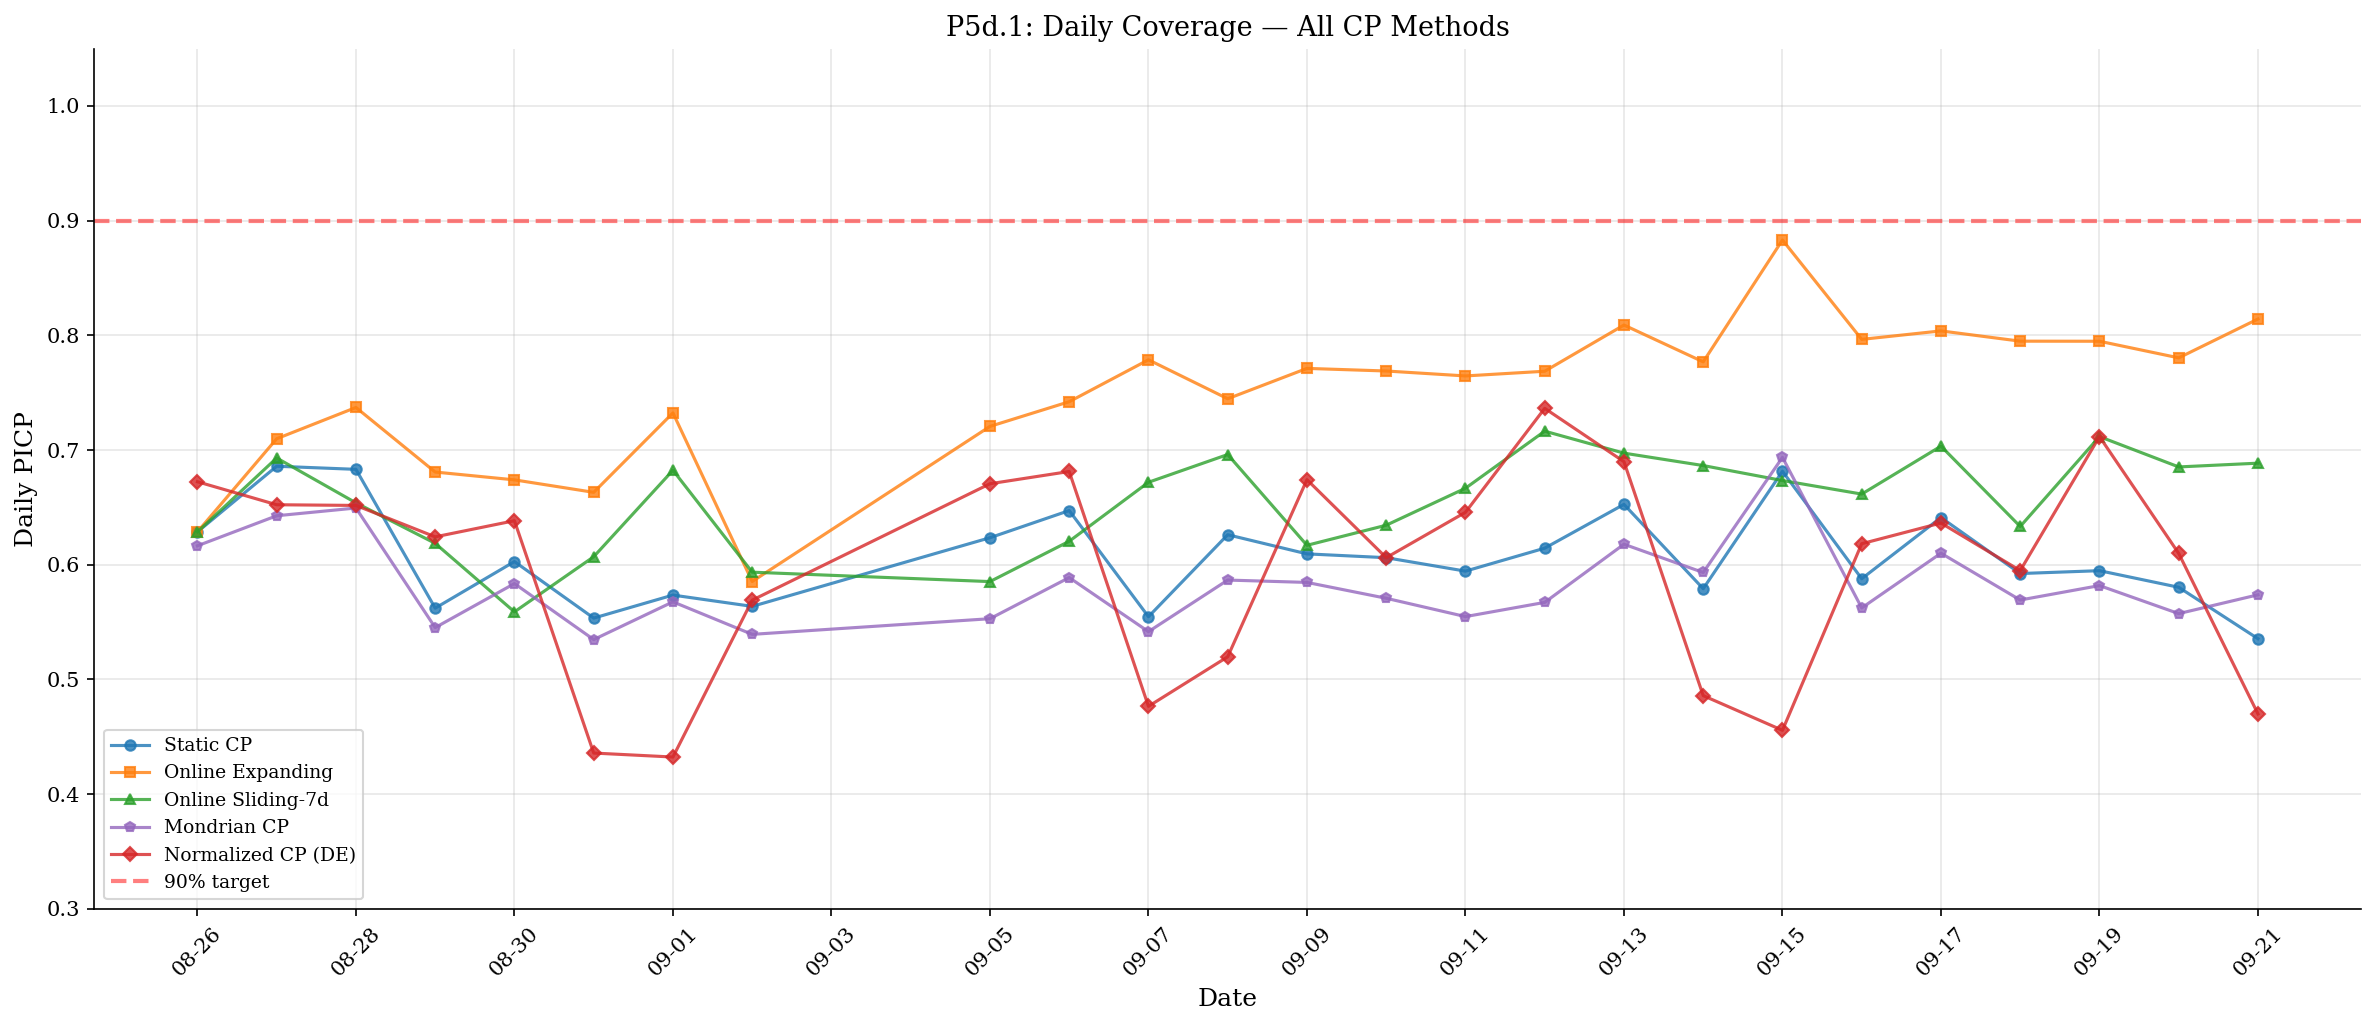

In [13]:
set_thesis_style()
fig, ax = plt.subplots(figsize=(16, 7))

plot_methods = ['Static CP', 'Online Expanding', 'Online Sliding-7d', 'Mondrian CP', 'Normalized CP (DE)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
markers = ['o', 's', '^', 'p', 'D']

for name, color, marker in zip(plot_methods, colors, markers):
    dm = daily_metrics[name]
    ax.plot(dm['date'], dm['PICP'], f'{marker}-', color=color,
            label=name, markersize=5, linewidth=1.5, alpha=0.8)

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='90% target')
ax.set_ylabel('Daily PICP')
ax.set_xlabel('Date')
ax.set_title('P5d.1: Daily Coverage — All CP Methods', fontsize=13)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0.3, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_1_daily_coverage.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_1_daily_coverage.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.1

Plot P5d.1 visualizes the daily PICP for all five methods. Static CP (blue circles) and Normalized CP (red diamonds) both use fixed calibration from W4, so their coverage trajectories are comparable — any difference is solely due to the difficulty-based interval scaling. Online methods (orange/green) can recover coverage through recalibration. Mondrian CP (purple) represents categorical adaptation. The plot reveals how each adaptation strategy handles the progressive distribution shift across test periods.

---
## Plot P5d.2: Interval Width Distribution — Static vs Normalized CP

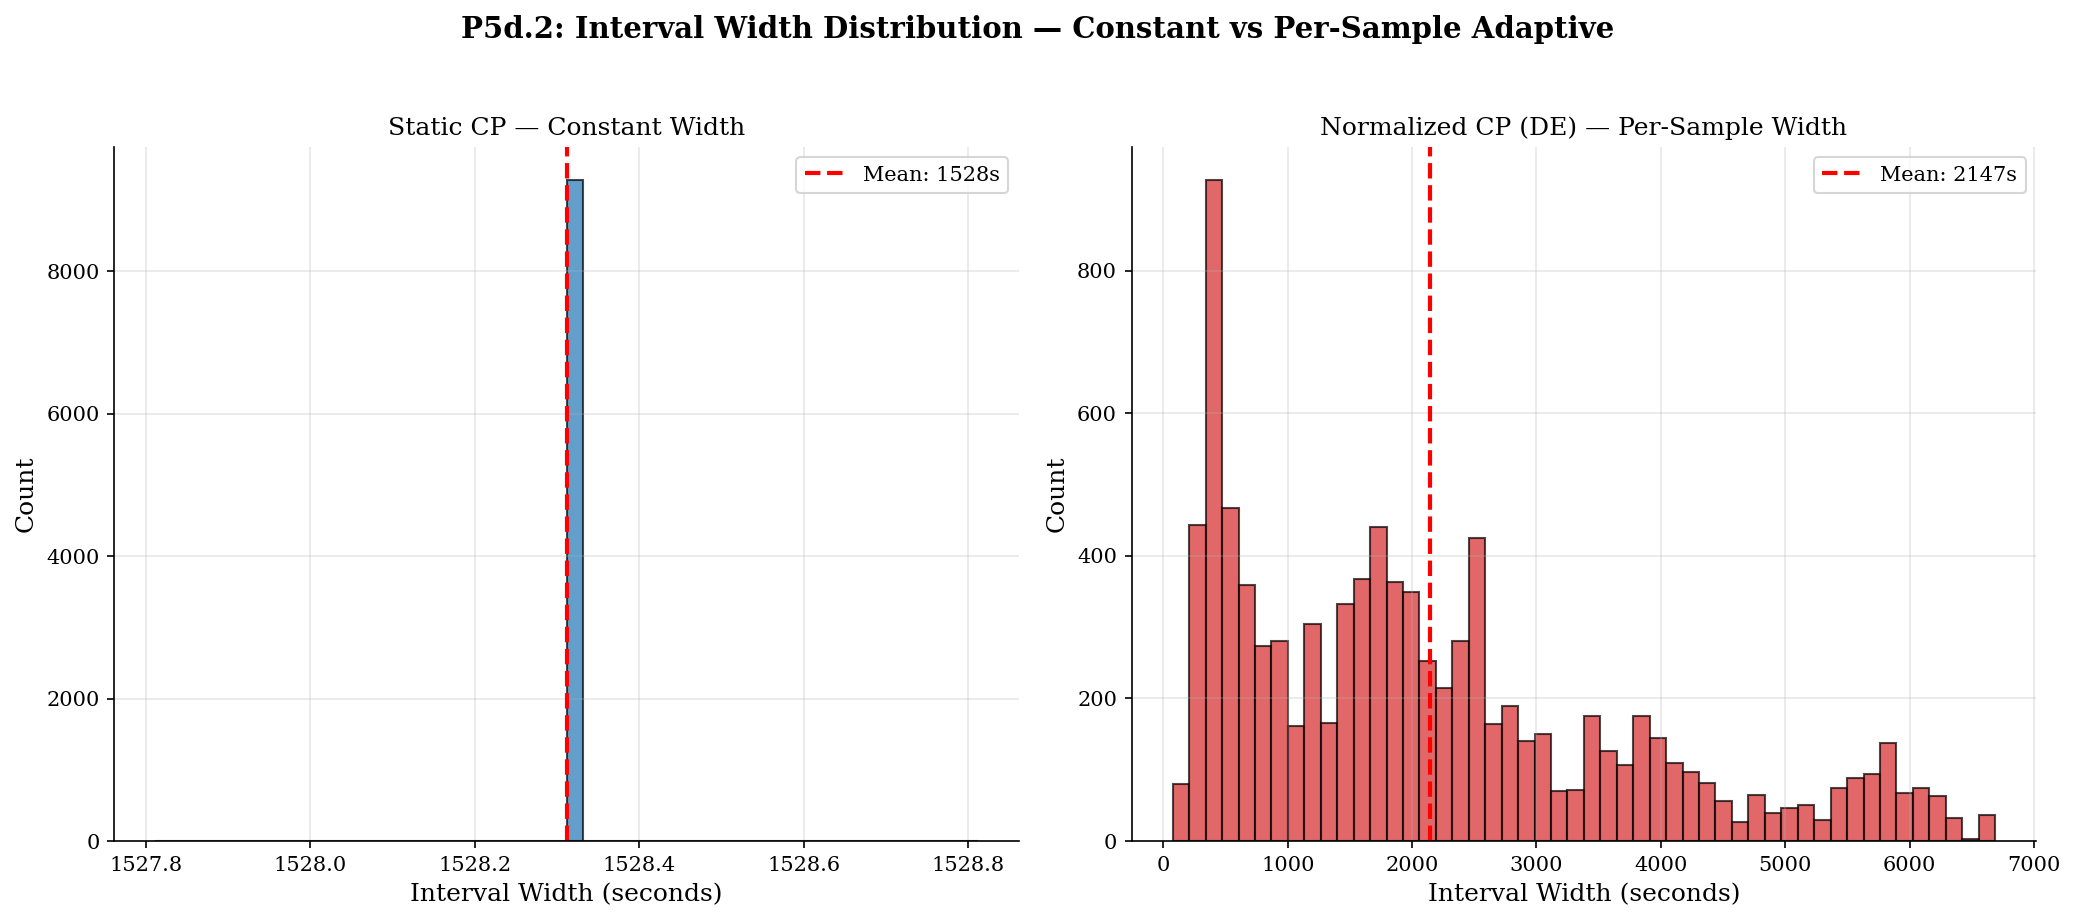

In [14]:
# Plot P5d.2: Interval width distributions
set_thesis_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Static CP widths (constant)
widths_static = upper_static - lower_static
axes[0].hist(widths_static, bins=50, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0].axvline(x=widths_static.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {widths_static.mean():.0f}s')
axes[0].set_xlabel('Interval Width (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Static CP — Constant Width', fontsize=12)
axes[0].legend()

# Normalized CP widths (per-sample)
widths_de = upper_de - lower_de
axes[1].hist(widths_de, bins=50, color='#d62728', alpha=0.7, edgecolor='black')
axes[1].axvline(x=widths_de.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {widths_de.mean():.0f}s')
axes[1].set_xlabel('Interval Width (seconds)')
axes[1].set_ylabel('Count')
axes[1].set_title('Normalized CP (DE) — Per-Sample Width', fontsize=12)
axes[1].legend()

fig.suptitle('P5d.2: Interval Width Distribution — Constant vs Per-Sample Adaptive',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_2_width_distribution.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_2_width_distribution.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.2

Plot P5d.2 provides the most direct visual evidence of how Normalized CP differs from Static CP. The left panel shows Static CP's constant interval width — a single spike at one value. The right panel shows Normalized CP's per-sample adaptive widths — a distribution that spans a wide range. The spread of the Normalized CP distribution reflects how much the difficulty estimator differentiates between easy and hard samples. Wider distributions indicate more aggressive adaptation; narrower distributions suggest the estimator finds most samples similarly difficult.

---
## Plot P5d.3: Coverage-Width Trade-off

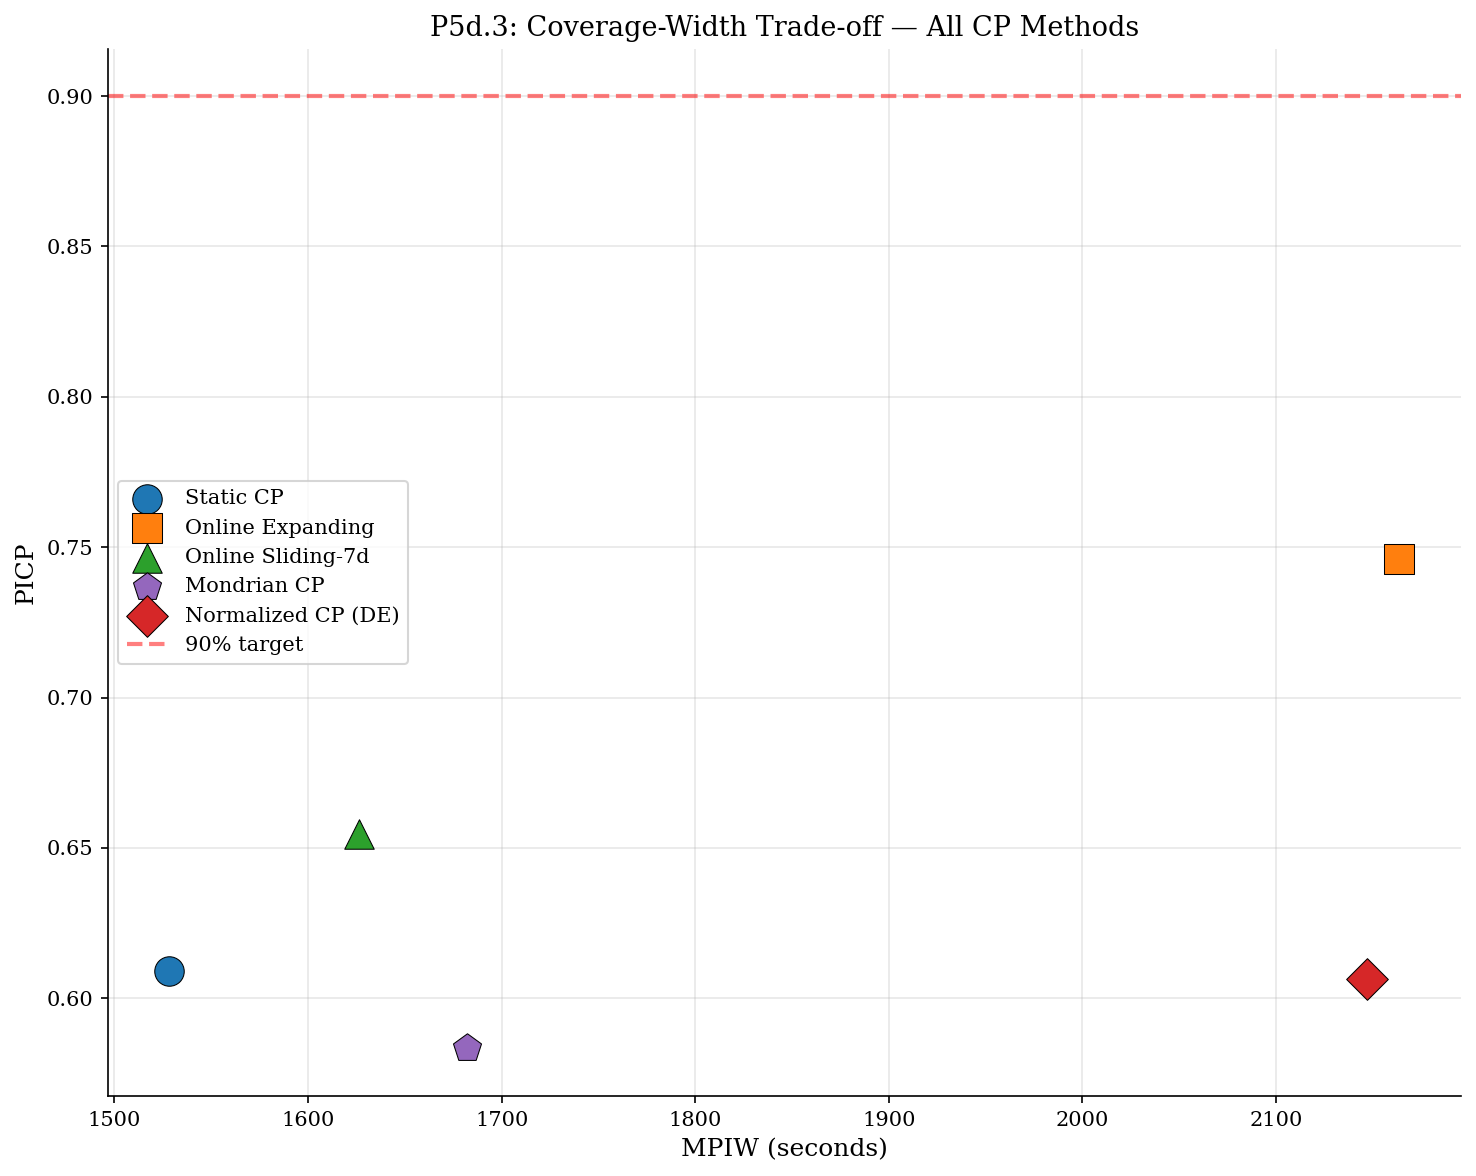

In [15]:
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 8))

for (name, m), color, marker in zip(methods.items(), colors, markers):
    met = m['metrics']
    ax.scatter(met['MPIW'], met['PICP'], s=200, c=color, marker=marker,
              label=name, edgecolors='black', linewidth=0.5, zorder=5)

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='90% target')
ax.set_xlabel('MPIW (seconds)', fontsize=12)
ax.set_ylabel('PICP', fontsize=12)
ax.set_title('P5d.3: Coverage-Width Trade-off — All CP Methods', fontsize=13)
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_3_tradeoff_scatter.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_3_tradeoff_scatter.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.3

Plot P5d.3 positions all methods in the PICP × MPIW space. The top-left quadrant (high coverage, narrow intervals) represents optimal performance. Points above the 0.90 target line have adequate coverage. The relative position of Normalized CP (DE) reveals its trade-off: if it lies above and to the left of Static CP, the difficulty estimator improves both coverage and efficiency. If it lies below, the per-sample scaling does not compensate for the calibration-to-test shift.

---
## Plot P5d.4: Difficulty Score vs Interval Width

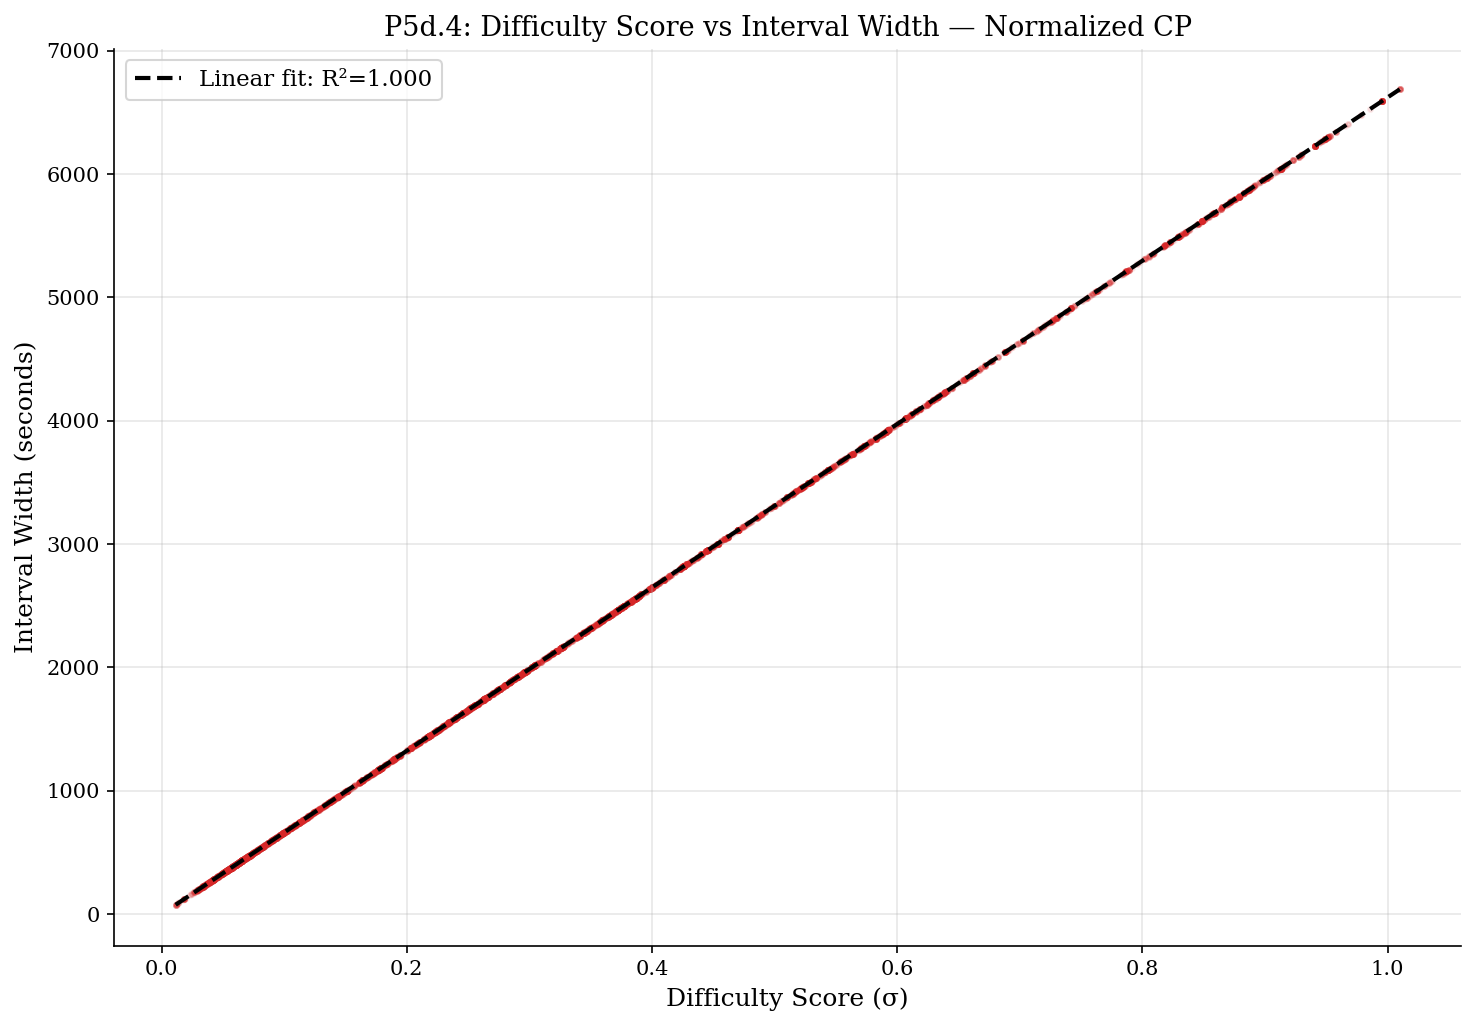

In [16]:
# Plot P5d.4: Sigma vs interval width (verification of linearity)
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter: sigma vs width
ax.scatter(sigma_test, widths_de, alpha=0.1, s=5, c='#d62728')
ax.set_xlabel('Difficulty Score (σ)', fontsize=12)
ax.set_ylabel('Interval Width (seconds)', fontsize=12)
ax.set_title('P5d.4: Difficulty Score vs Interval Width — Normalized CP', fontsize=13)

# Fit line
slope, intercept, r, p, se = stats.linregress(sigma_test, widths_de)
x_line = np.linspace(sigma_test.min(), sigma_test.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=2,
        label=f'Linear fit: R²={r**2:.3f}')
ax.legend(fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_4_sigma_vs_width.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_4_sigma_vs_width.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.4

Plot P5d.4 verifies the fundamental mechanism of Normalized CP: interval width scales linearly with difficulty score (σ). Each point is one test sample. The linear relationship confirms that `width = 2 × q_norm × σ` — higher difficulty produces proportionally wider intervals. The R² value quantifies how tightly the relationship holds (R² ≈ 1.0 expected for normalized CP). Any deviation from perfect linearity would indicate that the framework applies additional corrections beyond simple sigma scaling.

---
## Plot P5d.5: Difficulty by Category (time_period × route)

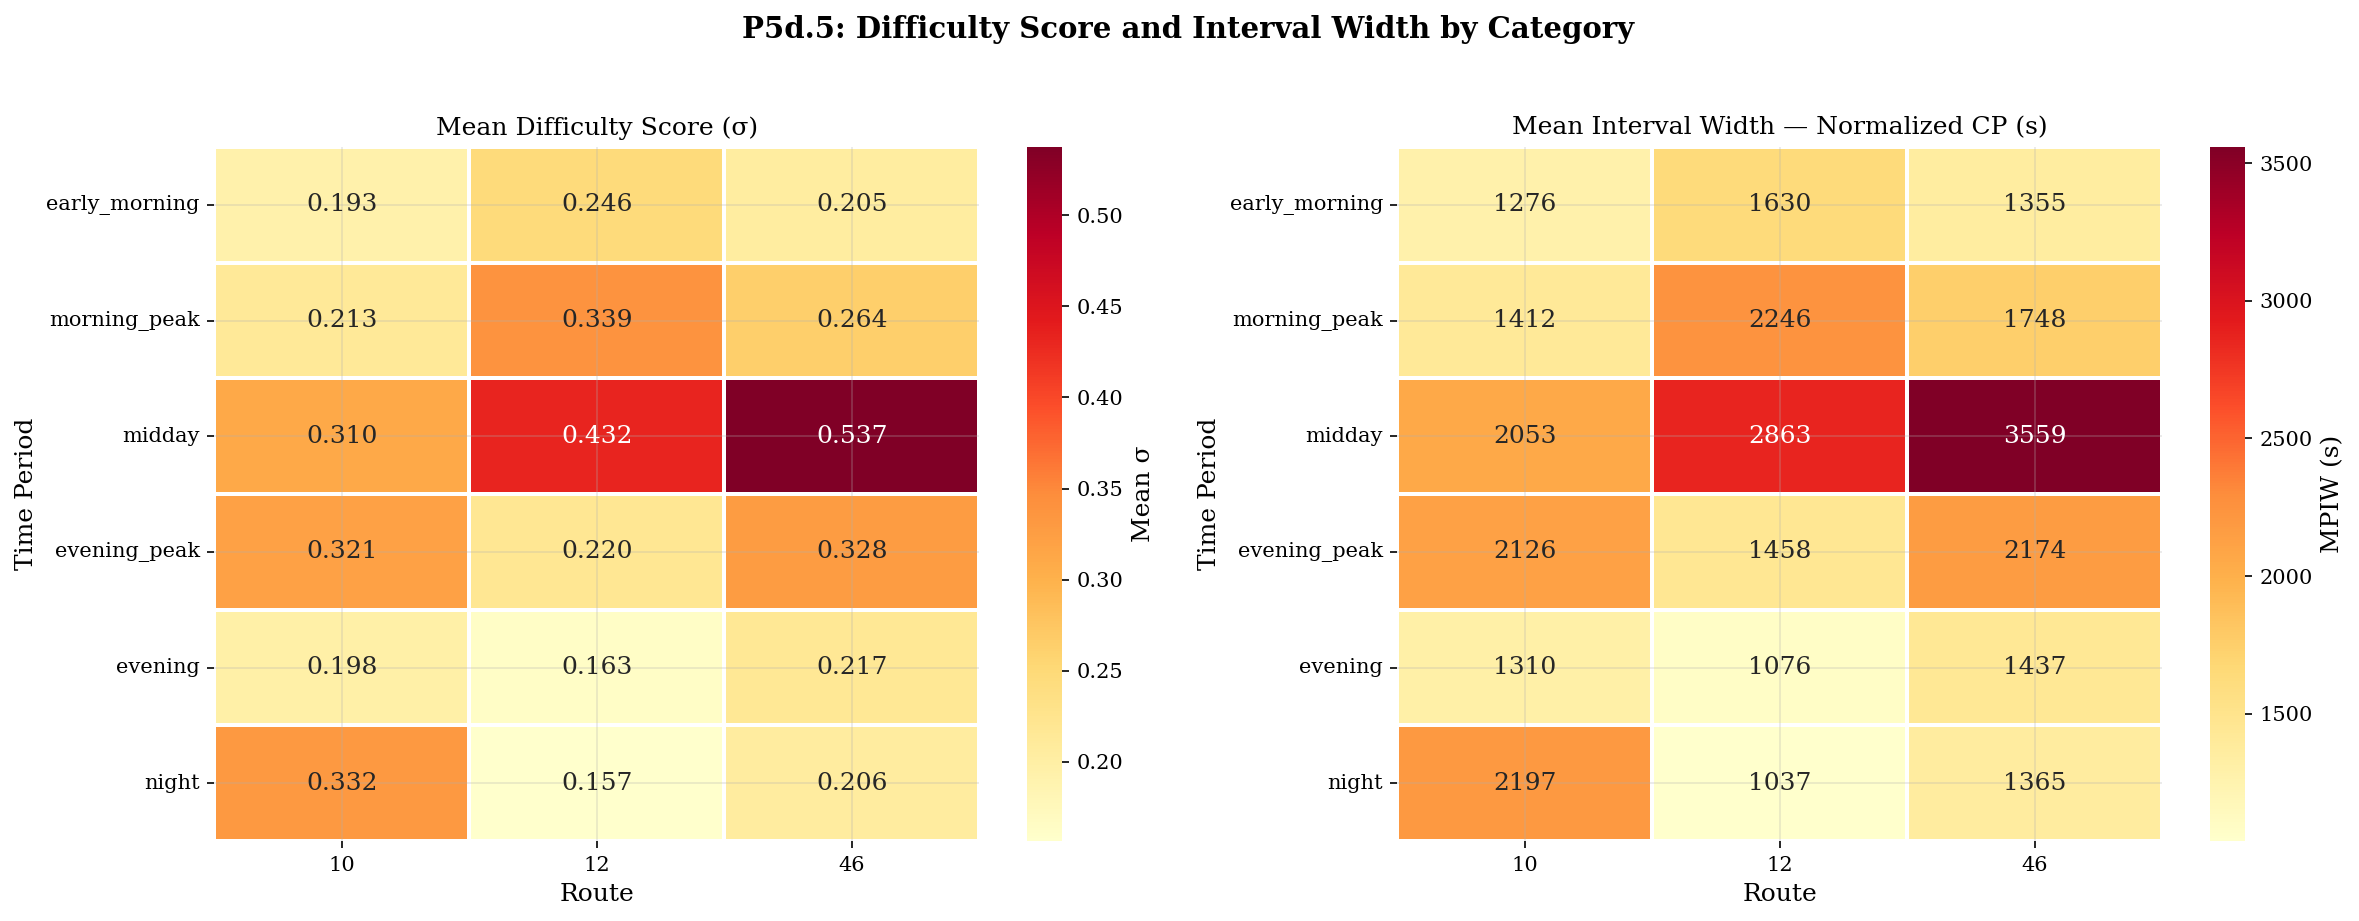

In [17]:
# Plot P5d.5: Mean difficulty by category
set_thesis_style()

# Add sigma to test dataframe
test_analysis = test_all[['time_period', 'route_short_name']].copy()
test_analysis['sigma'] = sigma_test
test_analysis['width_de'] = widths_de
test_analysis['width_static'] = widths_static

# Pivot: mean sigma by (time_period, route)
sigma_pivot = test_analysis.pivot_table(
    values='sigma', index='time_period', columns='route_short_name', aggfunc='mean'
)
from utils.conformal import MONDRIAN_VALID_TIME_PERIODS
tp_order = [tp for tp in MONDRIAN_VALID_TIME_PERIODS if tp in sigma_pivot.index]
if 'night' in sigma_pivot.index:
    tp_order.append('night')
sigma_pivot = sigma_pivot.reindex(tp_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Difficulty heatmap
sns.heatmap(
    sigma_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Mean σ'},
    ax=axes[0]
)
axes[0].set_title('Mean Difficulty Score (σ)', fontsize=12)
axes[0].set_ylabel('Time Period')
axes[0].set_xlabel('Route')

# Interval width heatmap (Normalized CP)
width_pivot = test_analysis.pivot_table(
    values='width_de', index='time_period', columns='route_short_name', aggfunc='mean'
)
width_pivot = width_pivot.reindex(tp_order)

sns.heatmap(
    width_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'MPIW (s)'},
    ax=axes[1]
)
axes[1].set_title('Mean Interval Width — Normalized CP (s)', fontsize=12)
axes[1].set_ylabel('Time Period')
axes[1].set_xlabel('Route')

fig.suptitle('P5d.5: Difficulty Score and Interval Width by Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_5_difficulty_by_category.png'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_5_difficulty_by_category.pdf'),
            bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.5

Plot P5d.5 reveals how the difficulty estimator perceives different operational categories. The left heatmap shows mean difficulty scores per (time_period, route) — this is what the KNN-based estimator has learned from the calibration residuals. Higher difficulty (darker colors) indicates categories with larger typical prediction errors. The right heatmap translates these difficulty scores into actual interval widths under Normalized CP. This provides an intuitive operational interpretation: practitioners can see which route-time combinations are assigned the widest prediction uncertainty. The pattern should align with domain knowledge — e.g., peak hours on busy routes should have higher difficulty.

---
## Plot P5d.6: Sample Trip Intervals — Static vs Normalized CP

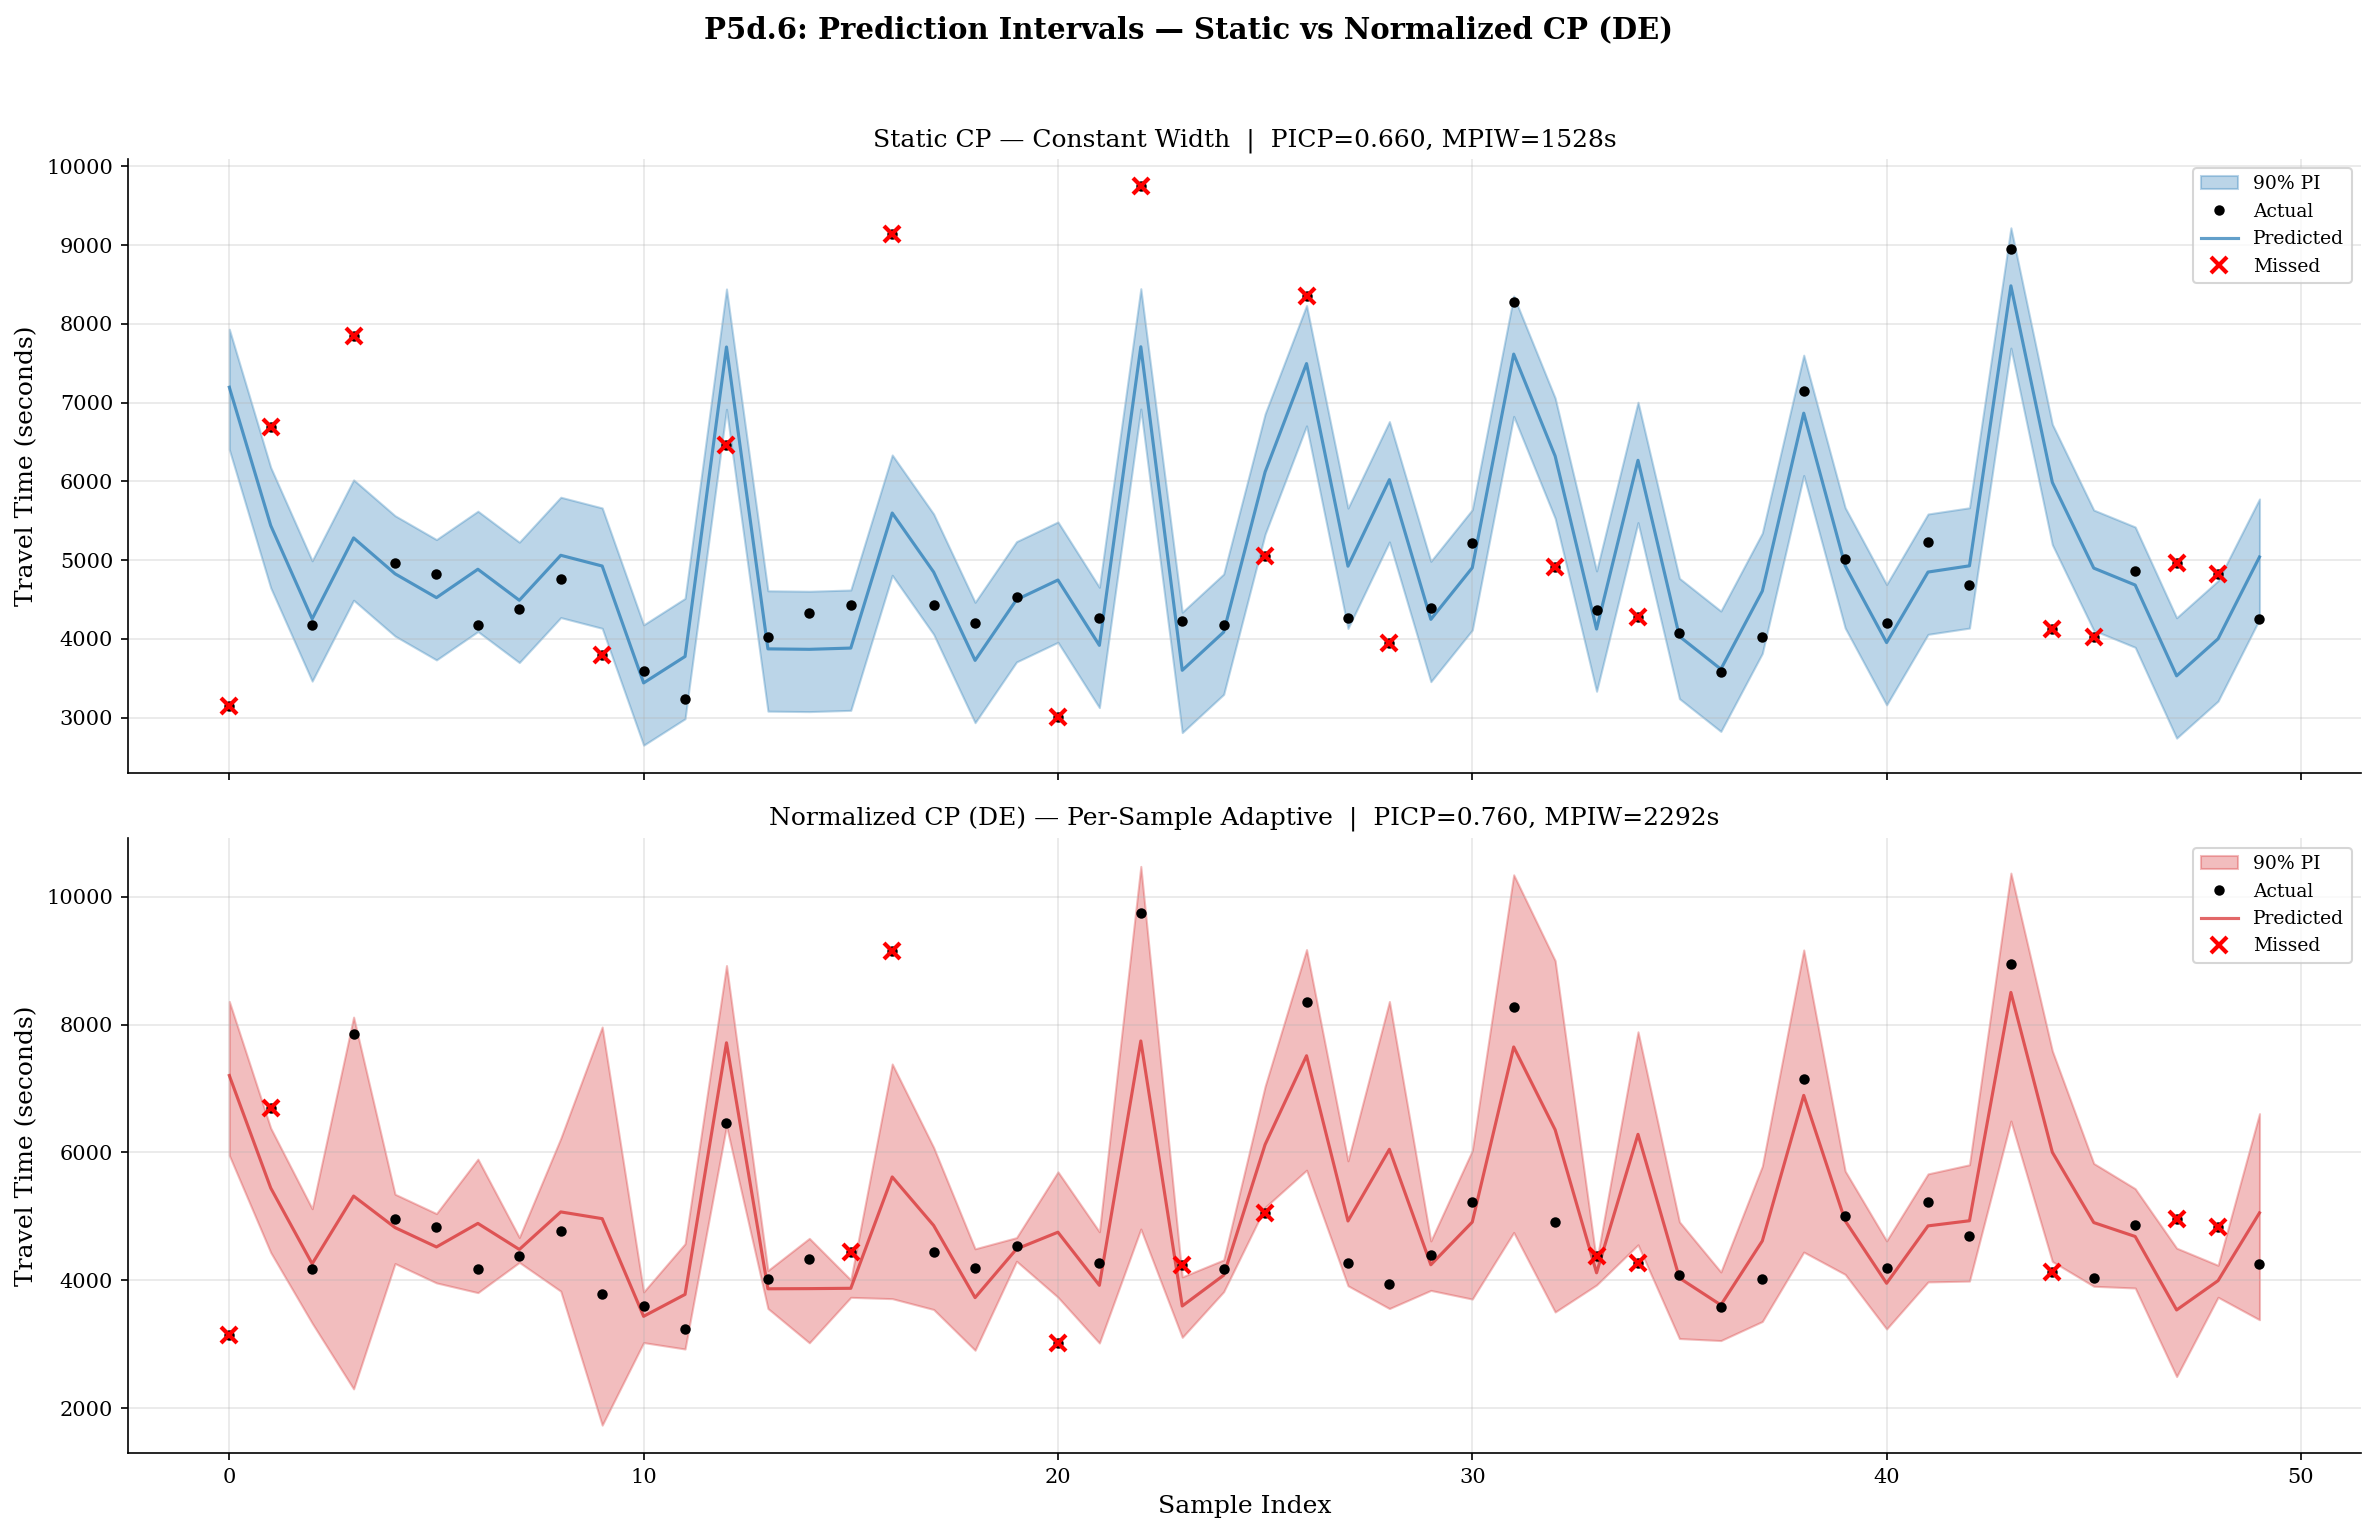

In [18]:
set_thesis_style()
N_SHOW = 50
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

np.random.seed(RANDOM_STATE)
sample_idx = np.sort(np.random.choice(len(y_test), size=N_SHOW, replace=False))
x = np.arange(N_SHOW)

for ax, name, lo, up, color, title in zip(
    axes,
    ['Static CP', 'Normalized CP (DE)'],
    [lower_static, lower_de],
    [upper_static, upper_de],
    ['#1f77b4', '#d62728'],
    ['Static CP — Constant Width', 'Normalized CP (DE) — Per-Sample Adaptive']
):
    y_s = y_test[sample_idx]
    lo_s = lo[sample_idx]
    up_s = up[sample_idx]
    pred_s = methods[name]['y_pred'][sample_idx]
    
    ax.fill_between(x, lo_s, up_s, alpha=0.3, color=color, label='90% PI')
    ax.plot(x, y_s, 'ko', markersize=4, label='Actual', zorder=5)
    ax.plot(x, pred_s, '-', color=color, linewidth=1.5, alpha=0.7, label='Predicted')
    
    missed = (y_s < lo_s) | (y_s > up_s)
    if missed.any():
        ax.plot(x[missed], y_s[missed], 'rx', markersize=8,
                markeredgewidth=2, label='Missed', zorder=6)
    
    picp_s = compute_picp(y_s, lo_s, up_s)
    mpiw_s = compute_mpiw(lo_s, up_s)
    ax.set_title(f'{title}  |  PICP={picp_s:.3f}, MPIW={mpiw_s:.0f}s', fontsize=12)
    ax.set_ylabel('Travel Time (seconds)')
    ax.legend(loc='upper right', fontsize=9)

axes[1].set_xlabel('Sample Index')
fig.suptitle('P5d.6: Prediction Intervals — Static vs Normalized CP (DE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5d_6_sample_intervals.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5d_6_sample_intervals.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5d.6

Plot P5d.6 provides a concrete visual comparison. The top panel (Static CP) shows a uniform blue band — the same width for every trip. The bottom panel (Normalized CP) shows a varying red band — wider for difficult trips and narrower for easy ones. Red × markers indicate missed predictions. The visual contrast demonstrates how difficulty estimation reallocates the uncertainty budget: samples that Static CP wastes width on (easy, predictable trips) get narrower intervals, while samples that Static CP under-covers (hard, variable trips) get wider intervals.

---
## 6. Conditional Coverage — Normalized CP by Category

In [19]:
# Conditional coverage by time_period and route
cond_rows = []

for period in ['test_near', 'test_mid', 'test_far']:
    mask_p = periods_test == period
    for name in ['Static CP', 'Normalized CP (DE)']:
        m = methods[name]
        
        # By time_period
        if 'time_period' in test_all.columns:
            tp_groups = test_all.loc[mask_p, 'time_period'].values
            for tp in np.unique(tp_groups):
                mask_tp = mask_p & (test_all['time_period'].values == tp)
                n = mask_tp.sum()
                if n < 10:
                    continue
                picp = compute_picp(y_test[mask_tp], m['lower'][mask_tp], m['upper'][mask_tp])
                mpiw = compute_mpiw(m['lower'][mask_tp], m['upper'][mask_tp])
                cond_rows.append({
                    'Method': name, 'Period': period, 'Group': 'time_period',
                    'Category': tp, 'PICP': picp, 'MPIW': mpiw, 'n': n
                })
        
        # By route
        if 'route_short_name' in test_all.columns:
            route_groups = test_all.loc[mask_p, 'route_short_name'].values
            for rt in np.unique(route_groups):
                mask_rt = mask_p & (test_all['route_short_name'].values == rt)
                n = mask_rt.sum()
                if n < 10:
                    continue
                picp = compute_picp(y_test[mask_rt], m['lower'][mask_rt], m['upper'][mask_rt])
                mpiw = compute_mpiw(m['lower'][mask_rt], m['upper'][mask_rt])
                cond_rows.append({
                    'Method': name, 'Period': period, 'Group': 'route',
                    'Category': rt, 'PICP': picp, 'MPIW': mpiw, 'n': n
                })

cond_df = pd.DataFrame(cond_rows)

# Show conditional coverage by time_period
print("Conditional Coverage by time_period (averaged across test periods):")
tp_summary = cond_df[cond_df['Group'] == 'time_period'].pivot_table(
    values='PICP', index='Category', columns='Method', aggfunc='mean'
)
display(tp_summary.style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', vmin=0.50, vmax=1.0
).set_caption('Conditional PICP by time_period — Static vs Normalized CP'))

Conditional Coverage by time_period (averaged across test periods):


Method,Normalized CP (DE),Static CP
Category,,
early_morning,0.6513,0.7407
evening,0.5321,0.6256
evening_peak,0.5945,0.5960
midday,0.6145,0.5531
morning_peak,0.6044,0.6567
night,0.1000,0.2500


---
## 7. Statistical Significance

In [20]:
# Statistical tests: pairwise comparisons against Normalized CP (DE)
sig_rows = []

ref_name = 'Normalized CP (DE)'
ref = methods[ref_name]

for comp_name in ['Static CP', 'Online Expanding', 'Online Sliding-7d', 'Mondrian CP']:
    comp = methods[comp_name]
    
    covered_ref = ((y_test >= ref['lower']) & (y_test <= ref['upper'])).astype(int)
    covered_comp = ((y_test >= comp['lower']) & (y_test <= comp['upper'])).astype(int)
    
    # McNemar
    only_ref = ((covered_ref == 1) & (covered_comp == 0)).sum()
    only_comp = ((covered_ref == 0) & (covered_comp == 1)).sum()
    
    if only_ref + only_comp > 0:
        mcnemar_stat = (only_ref - only_comp)**2 / (only_ref + only_comp)
        mcnemar_p = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
    else:
        mcnemar_stat, mcnemar_p = 0, 1.0
    
    # Winkler comparison
    w_ref = (ref['upper'] - ref['lower']).copy()
    below = y_test < ref['lower']
    above = y_test > ref['upper']
    w_ref[below] += (2/ALPHA) * (ref['lower'][below] - y_test[below])
    w_ref[above] += (2/ALPHA) * (y_test[above] - ref['upper'][above])
    
    w_comp = (comp['upper'] - comp['lower']).copy()
    below_c = y_test < comp['lower']
    above_c = y_test > comp['upper']
    w_comp[below_c] += (2/ALPHA) * (comp['lower'][below_c] - y_test[below_c])
    w_comp[above_c] += (2/ALPHA) * (y_test[above_c] - comp['upper'][above_c])
    
    diff = w_ref - w_comp
    if np.any(diff != 0):
        _, wilcox_p = wilcoxon(w_ref, w_comp)
    else:
        wilcox_p = 1.0
    
    sig_rows.append({
        'Comparison': f"{ref_name} vs {comp_name}",
        'DE PICP': covered_ref.mean(),
        f'{comp_name} PICP': covered_comp.mean(),
        'McNemar p': mcnemar_p,
        'Wilcoxon p': wilcox_p,
        'Sig.': '***' if min(mcnemar_p, wilcox_p) < 0.001 else (
            '**' if min(mcnemar_p, wilcox_p) < 0.01 else (
            '*' if min(mcnemar_p, wilcox_p) < 0.05 else 'ns')),
    })

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.format({
    'DE PICP': '{:.4f}', 'McNemar p': '{:.4f}', 'Wilcoxon p': '{:.4f}',
}).set_caption('Table T5d.3: Statistical Significance — Normalized CP vs All Methods'))

# Save
sig_latex = sig_df.to_latex(
    index=False, float_format='%.4f',
    caption='Statistical Significance — Normalized CP (DE) vs Other Methods',
    label='tab:t5d_3_significance'
)
with open(os.path.join(TABLE_DIR, 'T5d_3_significance.tex'), 'w') as f:
    f.write(sig_latex)
print(f"Saved: T5d_3_significance.tex")

,Comparison,DE PICP,Static CP PICP,McNemar p,Wilcoxon p,Sig.,Online Expanding PICP,Online Sliding-7d PICP,Mondrian CP PICP
0,Normalized CP (DE) vs Static CP,0.6065,0.609099,0.6439,0.0000,***,nan,nan,nan
1,Normalized CP (DE) vs Online Expanding,0.6065,nan,0.0000,0.1103,***,0.746227,nan,nan
2,Normalized CP (DE) vs Online Sliding-7d,0.6065,nan,0.0000,0.0048,***,nan,0.654700,nan
3,Normalized CP (DE) vs Mondrian CP,0.6065,nan,0.0000,0.0000,***,nan,nan,0.583333


Saved: T5d_3_significance.tex


### Interpretation — Table T5d.3

Table T5d.3 tests whether the differences between Normalized CP (DE) and each baseline are statistically significant. McNemar's test evaluates coverage differences (binary: covered or not), while the Wilcoxon signed-rank test evaluates Winkler score differences (continuous: interval quality). A significant result (p < 0.05) confirms that the observed performance gap is not due to random variation. The comparison against Static CP isolates the pure effect of difficulty estimation; the comparison against Online CP reveals whether per-sample adaptation can match temporal recalibration.

---
## Experiment 2d Conclusion

In [21]:
print("=" * 70)
print("EXPERIMENT 2d SUMMARY — Normalized CP with DifficultyEstimator")
print("=" * 70)
print(f"\nDifficulty Estimator: KNN (k=25, residual-based, scaler=True)")
print(f"Calibration: W4 (fixed, same as Static CP)")
print(f"Confidence: {TARGET_COVERAGE*100:.0f}%")
print(f"\n{'Method':<25s} {'PICP':>8s} {'MPIW (s)':>10s} {'Winkler':>10s} {'Time (s)':>10s}")
print("-" * 65)
for name, m in methods.items():
    met = m['metrics']
    print(f"{name:<25s} {met['PICP']:>8.4f} {met['MPIW']:>10.1f} {met['Winkler_Score']:>10.1f} {m['time']:>10.1f}")

# Key finding
best_winkler = min(methods.keys(), key=lambda k: methods[k]['metrics']['Winkler_Score'])
print(f"\nBest Winkler Score: {best_winkler}")
print(f"  → {methods[best_winkler]['metrics']['Winkler_Score']:.1f}")

EXPERIMENT 2d SUMMARY — Normalized CP with DifficultyEstimator

Difficulty Estimator: KNN (k=25, residual-based, scaler=True)
Calibration: W4 (fixed, same as Static CP)
Confidence: 90%

Method                        PICP   MPIW (s)    Winkler   Time (s)
-----------------------------------------------------------------
Static CP                   0.6091     1528.3     9544.6       17.6
Online Expanding            0.7462     2163.8     7465.0       32.2
Online Sliding-7d           0.6547     1626.3     8728.9       24.2
Mondrian CP                 0.5833     1682.3     9265.1       18.5
Normalized CP (DE)          0.6065     2147.2     6968.1       21.0

Best Winkler Score: Normalized CP (DE)
  → 6968.1


---
## 8. Save Results

In [22]:
# Save results

# 1. Per-sample predictions
results_df = pd.DataFrame({
    'date': dates_test,
    'period': periods_test,
    'y_true': y_test,
    'sigma': sigma_test,
    # Static CP
    'pred_static': y_pred_static,
    'lower_static': lower_static,
    'upper_static': upper_static,
    # Online Expanding
    'pred_online_exp': y_pred_online_exp,
    'lower_online_exp': lower_online_exp,
    'upper_online_exp': upper_online_exp,
    # Online Sliding-7d
    'pred_online_s7': y_pred_online_s7,
    'lower_online_s7': lower_online_s7,
    'upper_online_s7': upper_online_s7,
    # Mondrian CP
    'pred_mondrian': y_pred_mondrian,
    'lower_mondrian': lower_mondrian,
    'upper_mondrian': upper_mondrian,
    # Normalized CP (DE)
    'pred_de': y_pred_de,
    'lower_de': lower_de,
    'upper_de': upper_de,
})

if 'time_period' in test_all.columns:
    results_df['time_period'] = test_all['time_period'].values
if 'route_short_name' in test_all.columns:
    results_df['route_short_name'] = test_all['route_short_name'].values

results_path = os.path.join(RESULTS_DIR, 'exp2d_difficulty_results.parquet')
results_df.to_parquet(results_path, index=False)
print(f"Saved predictions: {results_path} ({len(results_df):,} rows)")

# 2. Metrics JSON
metrics_summary = {
    'experiment': 'Phase5d_Exp2d_DifficultyEstimator',
    'target_coverage': TARGET_COVERAGE,
    'difficulty_estimator': {'type': 'knn', 'k': 25, 'scaler': True, 'beta': 0.01},
    'n_test_samples': int(len(y_test)),
    'n_cal_samples': int(len(y_cal)),
    'sigma_stats': {
        'cal_mean': float(sigma_cal.mean()), 'cal_std': float(sigma_cal.std()),
        'test_mean': float(sigma_test.mean()), 'test_std': float(sigma_test.std()),
    },
    'methods': {}
}
for name, m in methods.items():
    met = m['metrics']
    metrics_summary['methods'][name] = {
        k: float(v) if isinstance(v, (np.floating, float, np.integer, int)) else v
        for k, v in met.items()
    }
    metrics_summary['methods'][name]['time_seconds'] = float(m['time'])

metrics_path = os.path.join(RESULTS_DIR, 'exp2d_difficulty_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"Saved metrics: {metrics_path}")

# 3. Conditional coverage
if len(cond_rows) > 0:
    cond_path = os.path.join(RESULTS_DIR, 'exp2d_conditional_coverage.csv')
    cond_df.to_csv(cond_path, index=False)
    print(f"Saved conditional coverage: {cond_path}")

print("\n" + u"\u2713" + " Experiment 2d results saved successfully.")

Saved predictions: ../outputs/processed_data/phase5d/exp2d_difficulty_results.parquet (9,276 rows)
Saved metrics: ../outputs/processed_data/phase5d/exp2d_difficulty_metrics.json
Saved conditional coverage: ../outputs/processed_data/phase5d/exp2d_conditional_coverage.csv

✓ Experiment 2d results saved successfully.
